In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

2026-06-29 00:30:20.018933: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782693020.335531      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782693020.425097      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782693021.146950      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782693021.147006      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782693021.147009      16 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: []


2026-06-29 00:30:40.808604: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
strategy = tf.distribute.MirroredStrategy()
print("Number of devices:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
Number of devices: 1


In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training",
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=(28,28),
    batch_size=None,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing",
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=(28,28),
    batch_size=None,
    shuffle=False
)

x_train = []
y_train = []

for image, label in train_ds:
    x_train.append(image.numpy())
    y_train.append(label.numpy())

x_test = []
y_test = []

for image, label in test_ds:
    x_test.append(image.numpy())
    y_test.append(label.numpy())

x_train = np.array(x_train, dtype="float32") / 255.
y_train = np.array(y_train)

x_test = np.array(x_test, dtype="float32") / 255.
y_test = np.array(y_test)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
(60000, 28, 28, 1)
(60000,)
(10000, 28, 28, 1)
(10000,)


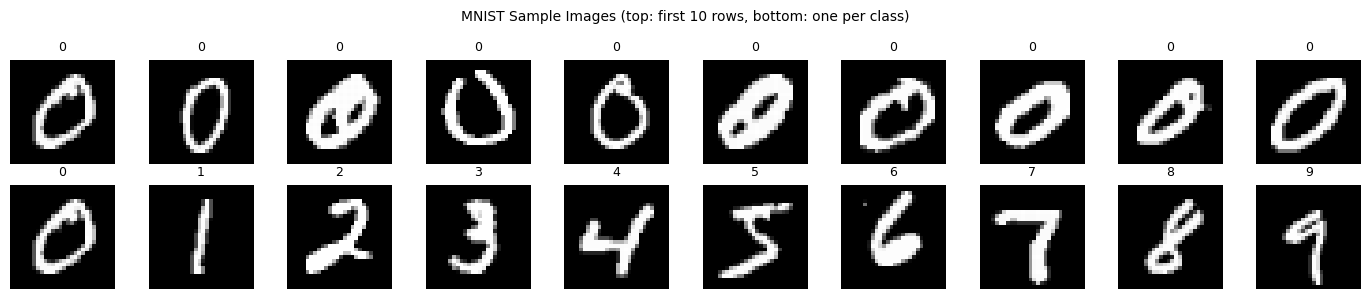

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))

for i in range(10):
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[0, i].set_title(str(y_train[i]), fontsize=9)
    axes[0, i].axis('off')

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes[1, digit].imshow(x_train[idx].squeeze(), cmap='gray')
    axes[1, digit].set_title(str(digit), fontsize=9)
    axes[1, digit].axis('off')

plt.suptitle('MNIST Sample Images (top: first 10 rows, bottom: one per class)', fontsize=10)
plt.tight_layout()
plt.show()

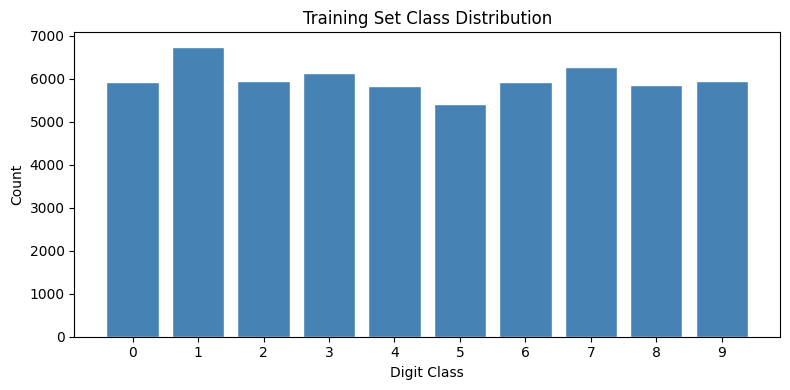

Class counts:
  0: 5923
  1: 6742
  2: 5958
  3: 6131
  4: 5842
  5: 5421
  6: 5918
  7: 6265
  8: 5851
  9: 5949


In [5]:
# class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar(unique, counts, color='steelblue', edgecolor='white')
plt.xlabel('Digit Class')
plt.ylabel('Count')
plt.title('Training Set Class Distribution')
plt.xticks(unique)
plt.tight_layout()
plt.show()

print("Class counts:")
for d, c in zip(unique, counts):
    print(f"  {d}: {c}")

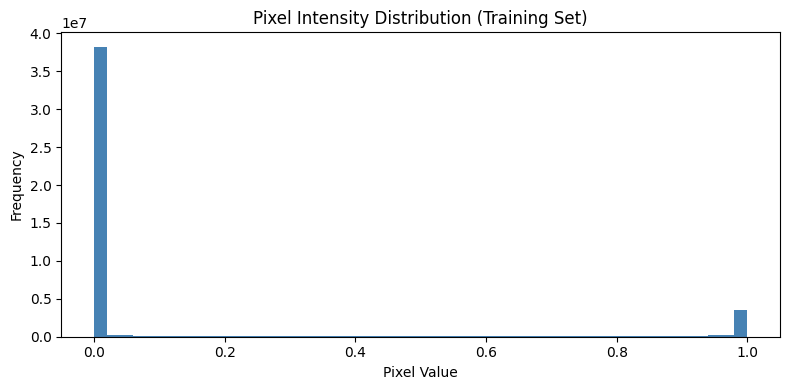

In [6]:
pixel_vals = x_train.flatten()
plt.figure(figsize=(8, 4))
plt.hist(pixel_vals, bins=50, color='steelblue', edgecolor='none')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Pixel Intensity Distribution (Training Set)')
plt.tight_layout()
plt.show()

In [7]:
np.random.seed(42)
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.randn(*x_train.shape)
x_test_noisy  = x_test  + noise_factor * np.random.randn(*x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0).astype('float32')
x_test_noisy  = np.clip(x_test_noisy,  0.0, 1.0).astype('float32')

print("Noisy train shape:", x_train_noisy.shape)
print("Noise factor used:", noise_factor)

Noisy train shape: (60000, 28, 28, 1)
Noise factor used: 0.4


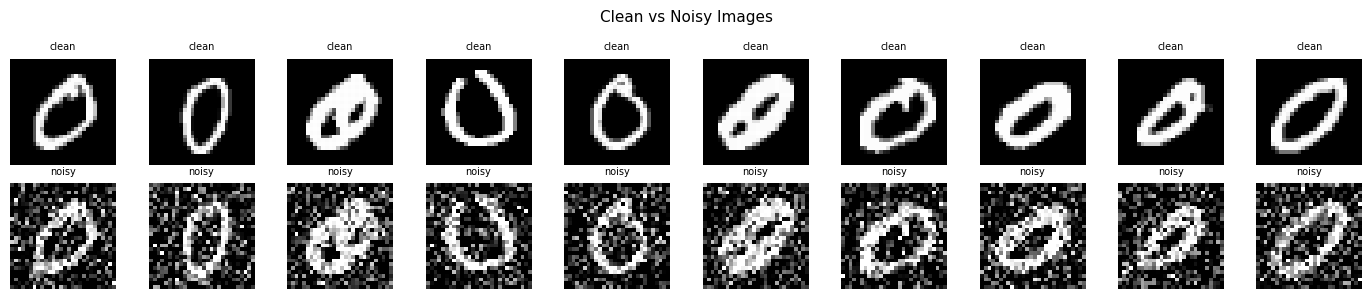

In [8]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[0, i].set_title('clean', fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray')
    axes[1, i].set_title('noisy', fontsize=7)
    axes[1, i].axis('off')

plt.suptitle('Clean vs Noisy Images', fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
with strategy.scope():
    inputs = keras.Input(shape=(28, 28, 1))

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = keras.Model(inputs, outputs, name='denoising_autoencoder')
    autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
EPOCHS     = 30
BATCH_SIZE = 256

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1)
]

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 75s 348ms/step - loss: 0.1147 - val_loss: 0.1044 - learning_rate: 0.0010
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 75s 354ms/step - loss: 0.1129 - val_loss: 0.1044 - learning_rate: 0.0010
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 76s 361ms/step - loss: 0.1129 - val_loss: 0.1044 - learning_rate: 0.0010
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - loss: 0.1127
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
211/211 ━━━━━━━━━━━━━━━━━━━━ 75s 354ms/step - loss: 0.1129 - val_loss: 0.1044 - learning_rate: 0.0010
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 74s 351ms/step - loss: 0.1129 - val_loss: 0.1044 - learning_rate: 5.0000e-04
Epoch 6/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 76s 361ms/step - loss: 0.1129 - val_loss: 0.1044 - learning_rate: 5.0000e-04


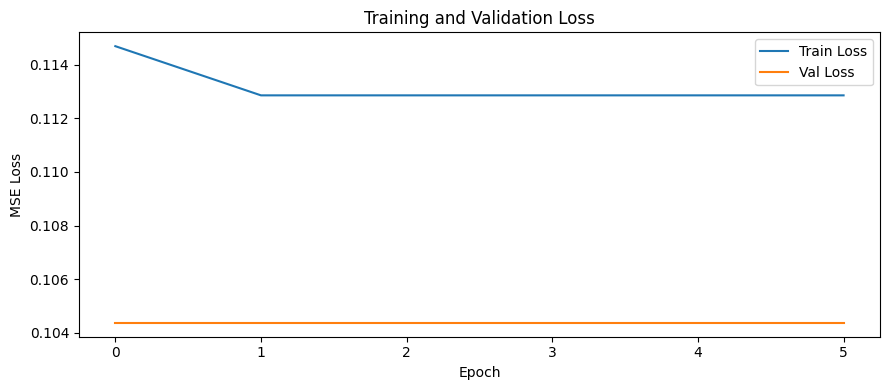

Best val loss: 0.10437


In [11]:
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best val loss: {min(history.history['val_loss']):.5f}")

In [12]:
test_loss = autoencoder.evaluate(x_test_noisy, x_test, batch_size=256, verbose=0)
print(f"Test MSE Loss: {test_loss:.5f}")

Test MSE Loss: 0.11396


40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step


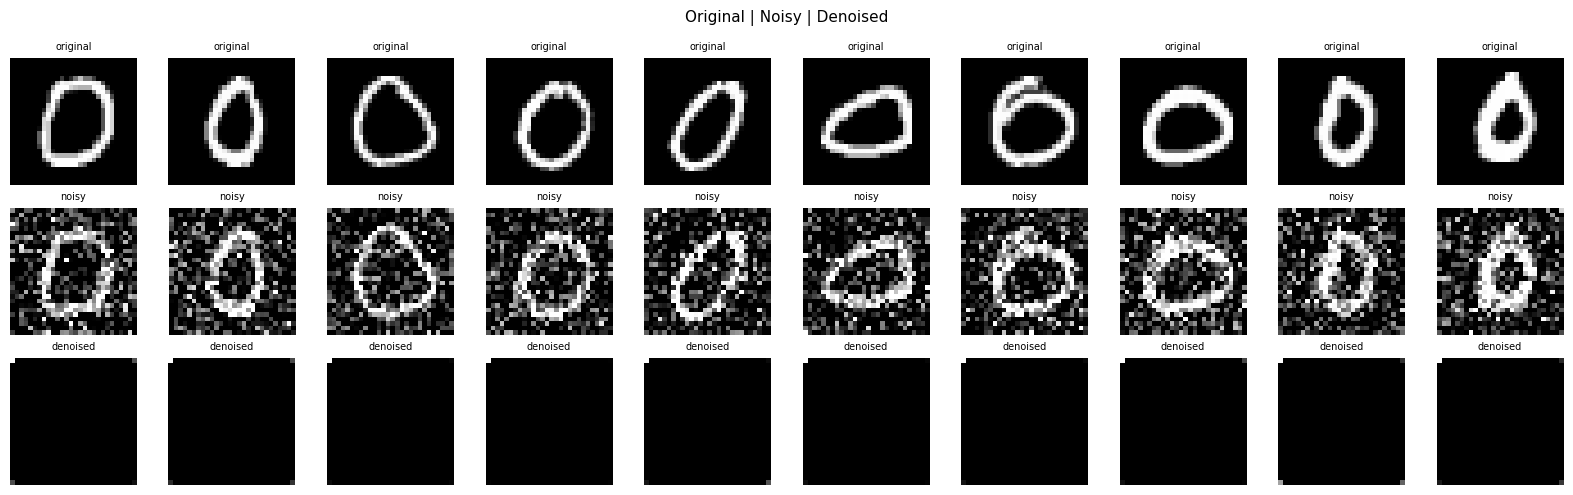

In [13]:
decoded_imgs = autoencoder.predict(x_test_noisy, batch_size=256)

n = 10
fig, axes = plt.subplots(3, n, figsize=(16, 5))

for i in range(n):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[0, i].set_title('original', fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[1, i].set_title('noisy', fontsize=7)
    axes[1, i].axis('off')

    axes[2, i].imshow(decoded_imgs[i].squeeze(), cmap='gray')
    axes[2, i].set_title('denoised', fontsize=7)
    axes[2, i].axis('off')

plt.suptitle('Original | Noisy | Denoised', fontsize=11)
plt.tight_layout()
plt.show()

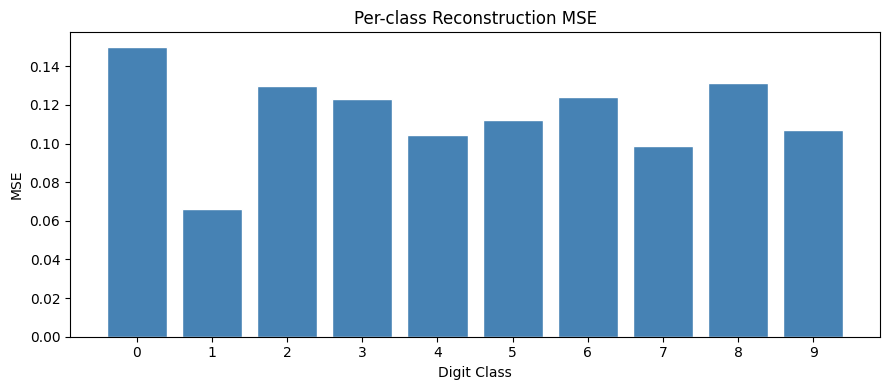

Per-class MSE:
  Digit 0: 0.15012
  Digit 1: 0.06630
  Digit 2: 0.12984
  Digit 3: 0.12312
  Digit 4: 0.10464
  Digit 5: 0.11214
  Digit 6: 0.12406
  Digit 7: 0.09865
  Digit 8: 0.13134
  Digit 9: 0.10694


In [14]:
per_class_mse = {}
for digit in range(10):
    idx = np.where(y_test == digit)[0]
    mse = np.mean((decoded_imgs[idx] - x_test[idx]) ** 2)
    per_class_mse[digit] = mse

plt.figure(figsize=(9, 4))
plt.bar(per_class_mse.keys(), per_class_mse.values(), color='steelblue', edgecolor='white')
plt.xlabel('Digit Class')
plt.ylabel('MSE')
plt.title('Per-class Reconstruction MSE')
plt.xticks(range(10))
plt.tight_layout()
plt.show()

print("Per-class MSE:")
for d, v in per_class_mse.items():
    print(f"  Digit {d}: {v:.5f}")

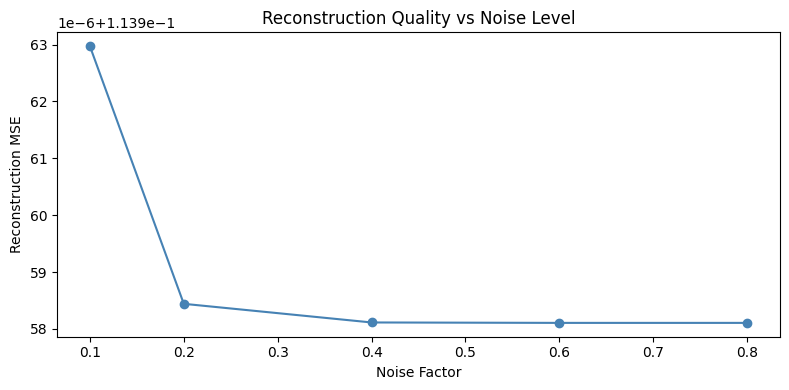

  Noise 0.1 -> MSE: 0.11396
  Noise 0.2 -> MSE: 0.11396
  Noise 0.4 -> MSE: 0.11396
  Noise 0.6 -> MSE: 0.11396
  Noise 0.8 -> MSE: 0.11396


In [15]:
noise_levels = [0.1, 0.2, 0.4, 0.6, 0.8]
results = {}

for nf in noise_levels:
    np.random.seed(42)
    x_noisy_test = np.clip(x_test + nf * np.random.randn(*x_test.shape), 0.0, 1.0).astype('float32')
    preds = autoencoder.predict(x_noisy_test, batch_size=256, verbose=0)
    mse = np.mean((preds - x_test) ** 2)
    results[nf] = mse

plt.figure(figsize=(8, 4))
plt.plot(list(results.keys()), list(results.values()), marker='o', color='steelblue')
plt.xlabel('Noise Factor')
plt.ylabel('Reconstruction MSE')
plt.title('Reconstruction Quality vs Noise Level')
plt.tight_layout()
plt.show()

for nf, mse in results.items():
    print(f"  Noise {nf:.1f} -> MSE: {mse:.5f}")

In [16]:
autoencoder.save('denoising_autoencoder_mnist.keras')
print("Model saved.")

Model saved.
